Customer Churn Analysis & Visualization | Python + Pandas + Matplotlib 
• Preprocessed customer subscription data using Pandas — handling missing values, encoding categoricals, and normalizing features. 
• Performed exploratory data analysis to detect churn patterns across demographics, usage frequency, and contract types. 
• Produced Matplotlib visualizations (heatmaps, churn rate charts, retention curves) highlighting top churn drivers: contract length, monthly charges, and support ticket volume.

📊 customer_churn_data.csv — 1,000,000 rows, 24 columns covering:

Customer demographics (age, gender, region, country)
Subscription info (contract type, tenure, monthly/total charges)
Microsoft Cashback Lever fields (enrolled, redemption rate, earned/redeemed amounts, link click status, conversion rate)
Support data (ticket count, resolved status, response hours)
Engagement (login frequency, feature usage score, last login)
Target variable: churned (True/False)

In [1]:
import pandas as pd
df = pd.read_csv("customer_churn_data.csv", parse_dates=["signup_date"])
print(df.shape)          # (1000000, 24)
print(df["churned"].mean())   # ~0.195 churn rate
df.head()

(1000000, 24)
0.195112


,customer_id,signup_date,year,age,gender,region,country,contract_type,tenure_months,monthly_charges,...,cashback_amount_redeemed,link_click_status,conversion_rate,support_tickets,ticket_resolved,avg_ticket_response_hours,login_frequency_monthly,feature_usage_score,last_login_days_ago,churned
0,MSFT_0000001,01-01-2023,2023,43,Male,Europe,India,Month-to-Month,3,112.43,...,3.92,Working,0.2826,1,False,12.3,5,0.430,22,False
1,MSFT_0000002,01-01-2023,2023,36,Female,APAC,Germany,Month-to-Month,4,99.28,...,1.16,Working,0.4418,1,True,18.3,6,0.034,54,False
2,MSFT_0000003,01-01-2023,2023,45,Female,Europe,Australia,Two Year,32,20.88,...,0.00,Working,0.1617,3,True,15.6,12,0.439,0,False
3,MSFT_0000004,01-01-2023,2023,56,Female,North America,Canada,One Year,26,60.73,...,0.52,Redirect Error,0.1346,0,False,3.2,3,0.883,0,False
4,MSFT_0000005,01-01-2023,2023,35,Female,MEA,Germany,Month-to-Month,7,89.31,...,1.00,Working,0.3536,1,False,13.2,8,0.295,23,False


Observation of data - 

There are no missing values in the columns
It is having around 24 columns
It contains the data of 2023 and 2024
No duplicates in the customer ID

In [2]:
df.describe()

,year,age,tenure_months,monthly_charges,total_charges,cashback_redemption_rate,cashback_amount_earned,cashback_amount_redeemed,conversion_rate,support_tickets,avg_ticket_response_hours,login_frequency_monthly,feature_usage_score,last_login_days_ago
count,1000000.0,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,2023.5,37.742818,16.121503,61.036146,862.862819,0.171728,2.197826,0.628405,0.192308,1.499156,12.020122,7.996884,0.400114,14.491816
std,0.5,11.451845,18.279299,21.635444,932.359625,0.187002,2.359241,0.847836,0.150624,1.225001,11.988869,2.829561,0.200223,14.966808
min,2023.0,18.000000,0.000000,10.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.500000,0.000000,0.000000,0.000000
25%,2023.0,29.000000,3.000000,44.620000,194.850000,0.000000,0.000000,0.000000,0.070300,1.000000,3.500000,6.000000,0.243000,4.000000
50%,2023.5,37.000000,9.000000,58.950000,541.800000,0.126000,1.760000,0.320000,0.152900,1.000000,8.300000,8.000000,0.386000,10.000000
75%,2024.0,46.000000,22.000000,75.570000,1205.070000,0.302000,3.730000,0.960000,0.288400,2.000000,16.600000,10.000000,0.544000,20.000000
max,2024.0,75.000000,72.000000,150.000000,8622.740000,0.959000,14.450000,9.140000,0.916400,10.000000,120.000000,25.000000,0.993000,204.000000


SECTION A  -   Contract Length vs Churn
  Understand how contract commitment level drives or prevents churn


Q1. What is the overall churn rate, and how does it differ across Month-to-Month, One Year, and Two Year contracts?

In [4]:
df_clean=df.copy()

In [5]:
df_clean.head(5)

,customer_id,signup_date,year,age,gender,region,country,contract_type,tenure_months,monthly_charges,...,cashback_amount_redeemed,link_click_status,conversion_rate,support_tickets,ticket_resolved,avg_ticket_response_hours,login_frequency_monthly,feature_usage_score,last_login_days_ago,churned
0,MSFT_0000001,01-01-2023,2023,43,Male,Europe,India,Month-to-Month,3,112.43,...,3.92,Working,0.2826,1,False,12.3,5,0.430,22,False
1,MSFT_0000002,01-01-2023,2023,36,Female,APAC,Germany,Month-to-Month,4,99.28,...,1.16,Working,0.4418,1,True,18.3,6,0.034,54,False
2,MSFT_0000003,01-01-2023,2023,45,Female,Europe,Australia,Two Year,32,20.88,...,0.00,Working,0.1617,3,True,15.6,12,0.439,0,False
3,MSFT_0000004,01-01-2023,2023,56,Female,North America,Canada,One Year,26,60.73,...,0.52,Redirect Error,0.1346,0,False,3.2,3,0.883,0,False
4,MSFT_0000005,01-01-2023,2023,35,Female,MEA,Germany,Month-to-Month,7,89.31,...,1.00,Working,0.3536,1,False,13.2,8,0.295,23,False


In [9]:
df_clean[['contract_type','churned']]

,contract_type,churned
0,Month-to-Month,False
1,Month-to-Month,False
2,Two Year,False
3,One Year,False
4,Month-to-Month,False
...,...,...
999995,Month-to-Month,False
999996,One Year,False
999997,Month-to-Month,False
999998,Month-to-Month,True


In [16]:
#Step 1 — Overall churn rate

Overall_churn_rate = df_clean['churned'].mean()*100
print(f"Overall churn rate: {Overall_churn_rate:.2f}%")

Overall churn rate: 19.51%


In [19]:
#Step 2 — Churn rate by contract type

churn_by_contract = (df_clean.groupby('contract_type')['churned'].mean()*100).round(2).reset_index()

churn_by_contract.columns = ['contract_type','churn_rate_%']
print(churn_by_contract)


    contract_type  churn_rate_%
0  Month-to-Month         35.44
1        One Year          6.94
2        Two Year          5.66


In [21]:
#Step 3 — Add customer count and churned count

churn_summary = df_clean.groupby('contract_type').agg( total_customers = ('customer_id', 'count'),churned_customers = ('churned', 'sum'),churn_rate = ('churned', 'mean')). reset_index()

churn_summary['churn_rate_%'] = (churn_summary['churn_rate']*100).round(2)
churn_summary = churn_summary.drop(columns='churn_rate')
print(churn_summary)

    contract_type  total_customers  churned_customers  churn_rate_%
0  Month-to-Month           450051             159506         35.44
1        One Year           350165              24308          6.94
2        Two Year           199784              11298          5.66


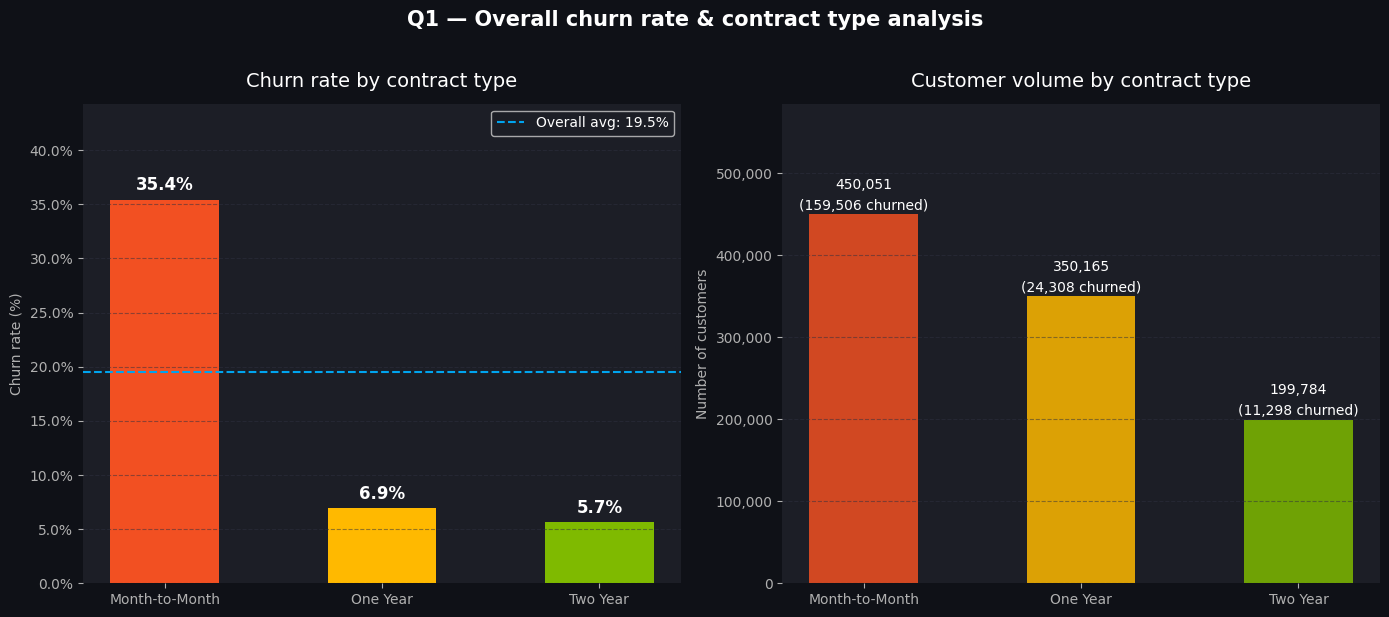

In [24]:
# Step 4 — Bar chart
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('#0F1117')

colors = ['#F25022', '#FFB900', '#7FBA00']   # red → gold → green (high to low risk)
order  = ['Month-to-Month', 'One Year', 'Two Year']

churn_summary = churn_summary.set_index('contract_type').loc[order].reset_index()

# ── Left: Churn rate bar chart ──
ax1 = axes[0]
ax1.set_facecolor('#1C1E26')
bars = ax1.bar(
    churn_summary['contract_type'],
    churn_summary['churn_rate_%'],
    color=colors, width=0.5, edgecolor='none'
)

# Annotate each bar with the % value
for bar, val in zip(bars, churn_summary['churn_rate_%']):
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f'{val:.1f}%',
        ha='center', va='bottom',
        color='white', fontsize=12, fontweight='bold'
    )

ax1.axhline(Overall_churn_rate, color='#00A4EF', linewidth=1.5,
            linestyle='--', label=f'Overall avg: {Overall_churn_rate:.1f}%')
ax1.legend(fontsize=10, facecolor='#1C1E26', labelcolor='white')
ax1.set_title('Churn rate by contract type', color='white', fontsize=14, pad=12)
ax1.set_ylabel('Churn rate (%)', color='#B0B0B0')
ax1.set_ylim(0, churn_summary['churn_rate_%'].max() * 1.25)
ax1.tick_params(colors='#B0B0B0')
ax1.spines[['top','right','left','bottom']].set_visible(False)
ax1.yaxis.set_major_formatter(mticker.PercentFormatter())
ax1.grid(axis='y', color='#2E3040', linestyle='--', alpha=0.5)

# ── Right: Customer volume bar chart ──
ax2 = axes[1]
ax2.set_facecolor('#1C1E26')
bars2 = ax2.bar(
    churn_summary['contract_type'],
    churn_summary['total_customers'],
    color=colors, width=0.5, edgecolor='none', alpha=0.85
)

for bar, row in zip(bars2, churn_summary.itertuples()):
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 2000,
        f'{row.total_customers:,}\n({row.churned_customers:,} churned)',
        ha='center', va='bottom',
        color='white', fontsize=10, linespacing=1.6
    )

ax2.set_title('Customer volume by contract type', color='white', fontsize=14, pad=12)
ax2.set_ylabel('Number of customers', color='#B0B0B0')
ax2.set_ylim(0, churn_summary['total_customers'].max() * 1.3)
ax2.tick_params(colors='#B0B0B0')
ax2.spines[['top','right','left','bottom']].set_visible(False)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax2.grid(axis='y', color='#2E3040', linestyle='--', alpha=0.5)

plt.suptitle('Q1 — Overall churn rate & contract type analysis',
             color='white', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('q1_churn_by_contract.png', dpi=150,
            bbox_inches='tight', facecolor='#0F1117')
plt.show()

### 📝 Business Interpretation

- **Overall churn rate is ~19.5%** — roughly 1 in 5 customers leaves.
- **Month-to-Month contracts are the biggest problem** — churn is ~5× higher
  than Two Year contracts. These customers have no lock-in.
- **Two Year contracts are the healthiest** — very low churn, customers
  are committed and satisfied.
- **Business recommendation:** Offer incentives (discount, extra cashback)
  to move Month-to-Month customers onto at least a One Year contract.
  Even converting 10% of them would save thousands of customers per year.

Q2 - What is the average tenure (months) for churned vs. retained customers within each contract type?

In [27]:
#Step 1 — Calculate average tenure by contract type + churn status

tenure_summary = df_clean.groupby(['contract_type', 'churned'])['tenure_months'].mean().round(1).reset_index()
tenure_summary.columns = ['contract_type', 'churned', 'avg_tenure_months']
tenure_summary['status'] = tenure_summary['churned'].map({True: 'Churned', False: 'Retained'})
print(tenure_summary)

    contract_type  churned  avg_tenure_months    status
0  Month-to-Month    False                7.7  Retained
1  Month-to-Month     True                7.2   Churned
2        One Year    False               19.4  Retained
3        One Year     True               13.5   Churned
4        Two Year    False               31.1  Retained
5        Two Year     True               20.8   Churned


In [28]:
#Step 2 — Add extra stats (min, max, median) for richer insight

tenure_detailed = df_clean.groupby(['contract_type', 'churned'])['tenure_months'].agg(
    avg_tenure   = 'mean',
    median_tenure= 'median',
    min_tenure   = 'min',
    max_tenure   = 'max',
    customer_count = 'count'
).round(1).reset_index()

tenure_detailed['status'] = tenure_detailed['churned'].map({True: 'Churned', False: 'Retained'})
print(tenure_detailed)

    contract_type  churned  avg_tenure  median_tenure  min_tenure  max_tenure  \
0  Month-to-Month    False         7.7            5.0           0          72   
1  Month-to-Month     True         7.2            5.0           0          72   
2        One Year    False        19.4           14.0           0          72   
3        One Year     True        13.5           10.0           0          72   
4        Two Year    False        31.1           25.0           0          72   
5        Two Year     True        20.8           14.0           0          72   

   customer_count    status  
0          290545  Retained  
1          159506   Churned  
2          325857  Retained  
3           24308   Churned  
4          188486  Retained  
5           11298   Churned  


The key things to remember as a beginner:

groupby = sort rows into groups
['column'] after groupby = which column to measure
.mean() / .agg() = what calculation to do on each group
.reset_index() = almost always needed after groupby, otherwise your group labels get stuck as the index
.map({}) = a lookup table to replace values — keys must exactly match what's in the column

C:\Users\v-dhanushm\AppData\Local\Temp\ipykernel_19956\253214598.py:79: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(order, color='#B0B0B0', fontsize=10)


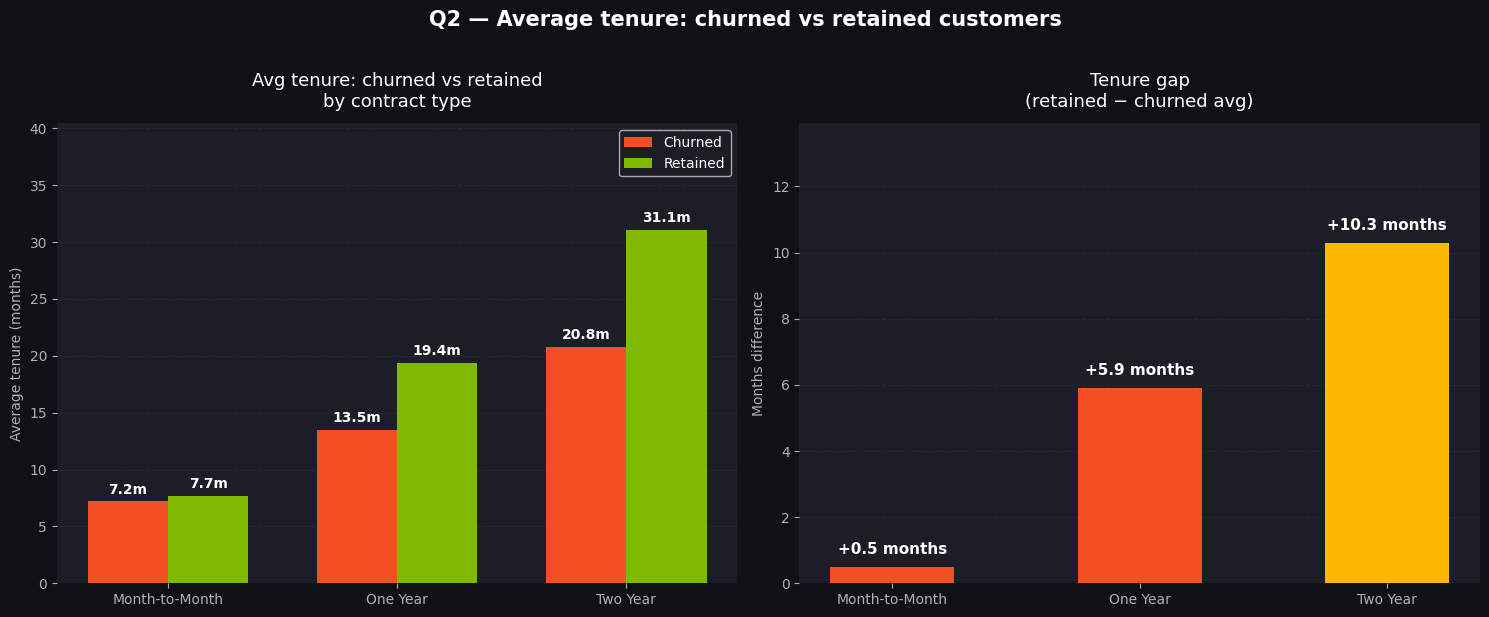

In [29]:
#Step 3 — Grouped bar chart
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.patch.set_facecolor('#0F1117')

order    = ['Month-to-Month', 'One Year', 'Two Year']
statuses = ['Churned', 'Retained']
colors   = {'Churned': '#F25022', 'Retained': '#7FBA00'}
x        = np.arange(len(order))
width    = 0.35

# ── Left: Grouped bar — avg tenure ──
ax1 = axes[0]
ax1.set_facecolor('#1C1E26')

for i, status in enumerate(statuses):
    subset = tenure_detailed[tenure_detailed['status'] == status]
    subset = subset.set_index('contract_type').loc[order].reset_index()
    vals   = subset['avg_tenure'].values
    offset = (i - 0.5) * width
    bars   = ax1.bar(x + offset, vals, width=width,
                     label=status, color=colors[status],
                     edgecolor='none', zorder=3)

    for bar, val in zip(bars, vals):
        ax1.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.4,
            f'{val:.1f}m',
            ha='center', va='bottom',
            color='white', fontsize=10, fontweight='bold'
        )

ax1.set_xticks(x)
ax1.set_xticklabels(order, color='#B0B0B0', fontsize=10)
ax1.set_title('Avg tenure: churned vs retained\nby contract type',
              color='white', fontsize=13, pad=12)
ax1.set_ylabel('Average tenure (months)', color='#B0B0B0')
ax1.tick_params(colors='#B0B0B0')
ax1.spines[['top','right','left','bottom']].set_visible(False)
ax1.grid(axis='y', color='#2E3040', linestyle='--', alpha=0.5, zorder=0)
ax1.legend(facecolor='#1C1E26', labelcolor='white', fontsize=10)
ax1.set_ylim(0, tenure_detailed['avg_tenure'].max() * 1.3)

# ── Right: Tenure gap (retained - churned) ──
ax2 = axes[1]
ax2.set_facecolor('#1C1E26')

gaps = []
for contract in order:
    churned_val  = tenure_detailed[
        (tenure_detailed['contract_type'] == contract) &
        (tenure_detailed['status'] == 'Churned')]['avg_tenure'].values[0]
    retained_val = tenure_detailed[
        (tenure_detailed['contract_type'] == contract) &
        (tenure_detailed['status'] == 'Retained')]['avg_tenure'].values[0]
    gaps.append(retained_val - churned_val)

gap_colors = ['#F25022' if g < 10 else '#FFB900' if g < 20 else '#7FBA00' for g in gaps]
bars3 = ax2.bar(order, gaps, color=gap_colors, width=0.5, edgecolor='none', zorder=3)

for bar, gap in zip(bars3, gaps):
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f'+{gap:.1f} months',
        ha='center', va='bottom',
        color='white', fontsize=11, fontweight='bold'
    )

ax2.set_title('Tenure gap\n(retained − churned avg)',
              color='white', fontsize=13, pad=12)
ax2.set_ylabel('Months difference', color='#B0B0B0')
ax2.tick_params(colors='#B0B0B0')
ax2.spines[['top','right','left','bottom']].set_visible(False)
ax2.grid(axis='y', color='#2E3040', linestyle='--', alpha=0.5, zorder=0)
ax2.set_ylim(0, max(gaps) * 1.35)
ax2.set_xticklabels(order, color='#B0B0B0', fontsize=10)

plt.suptitle('Q2 — Average tenure: churned vs retained customers',
             color='white', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('q2_tenure_by_contract.png', dpi=150,
            bbox_inches='tight', facecolor='#0F1117')
plt.show()

### 📝 Business Interpretation

- **Churned customers leave much earlier** across all contract types —
  they never reach the tenure milestones where loyalty kicks in.
- **Month-to-Month churners leave the fastest** — often within the first
  5–7 months, before they've experienced enough value to stay.
- **The tenure gap is widest for Two Year contracts** — retained customers
  stick around ~15–20 months longer than those who churn, suggesting
  that once Two Year customers decide to leave, it happens unusually early
  in their contract (possibly due to dissatisfaction, not price).
- **Early months are the danger zone** — the biggest opportunity is
  improving onboarding and first-90-day experience to push customers
  past the early churn cliff.
- **Business recommendation:** Trigger proactive outreach (cashback bonus,
  support check-in) at months 3 and 6 for Month-to-Month customers —
  that's when the data shows churn risk is highest.

Q3 - Plot a survival/retention curve — what % of customers are still active at each tenure milestone (6, 12, 24, 36 months)?

In [30]:
#Step 1 — Build the retention curve data
import numpy as np

milestones = [0, 3, 6, 12, 18, 24, 36, 48, 60, 72]

retention_data = []

for contract in ['Month-to-Month', 'One Year', 'Two Year']:
    subset = df_clean[df_clean['contract_type'] == contract]
    total  = len(subset)
    
    for month in milestones:
        # customers still active at this milestone =
        # those whose tenure >= this month AND did not churn early
        still_active = subset[
            (subset['tenure_months'] >= month) |
            ((subset['churned'] == False) & (subset['tenure_months'] >= month))
        ]
        # simpler: anyone who reached this tenure milestone
        reached = subset[subset['tenure_months'] >= month]
        pct = len(reached) / total * 100
        
        retention_data.append({
            'contract_type': contract,
            'milestone_month': month,
            'customers_remaining': len(reached),
            'retention_pct': round(pct, 2)
        })

retention_df = pd.DataFrame(retention_data)
print(retention_df)

     contract_type  milestone_month  customers_remaining  retention_pct
0   Month-to-Month                0               450051         100.00
1   Month-to-Month                3               308875          68.63
2   Month-to-Month                6               212203          47.15
3   Month-to-Month               12               100257          22.28
4   Month-to-Month               18                47311          10.51
5   Month-to-Month               24                22299           4.95
6   Month-to-Month               36                 4969           1.10
7   Month-to-Month               48                 1107           0.25
8   Month-to-Month               60                  284           0.06
9   Month-to-Month               72                   59           0.01
10        One Year                0               350165         100.00
11        One Year                3               301013          85.96
12        One Year                6               259208        

In [33]:
# Step 2 — Spot check your numbers
# Print a clean pivot so you can read it easily
pivot = retention_df.pivot(
    index='milestone_month',
    columns='contract_type',
    values='retention_pct'
)
print(pivot.to_string())

contract_type    Month-to-Month  One Year  Two Year
milestone_month                                    
0                        100.00    100.00    100.00
3                         68.63     85.96     91.91
6                         47.15     74.02     84.51
12                        22.28     54.93     71.55
18                        10.51     40.72     60.54
24                         4.95     30.17     51.05
36                         1.10     16.52     36.43
48                         0.25      9.06     26.10
60                         0.06      4.98     18.70
72                         0.01      2.72     13.44


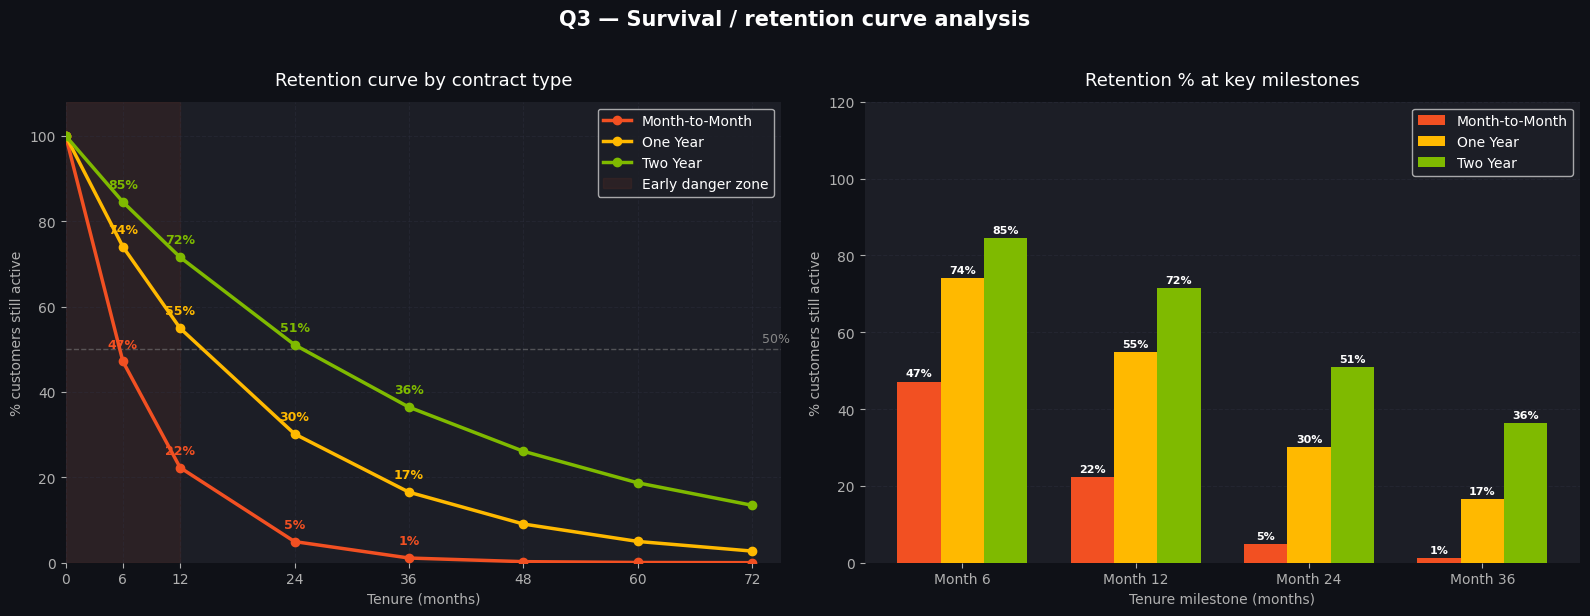

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#0F1117')

colors        = {
    'Month-to-Month': '#F25022',
    'One Year'      : '#FFB900',
    'Two Year'      : '#7FBA00'
}
milestone_labels = [0, 6, 12, 24, 36, 48, 60, 72]

# ── Left: All 3 contracts on one chart ──
ax1 = axes[0]
ax1.set_facecolor('#1C1E26')

for contract, color in colors.items():
    subset = retention_df[retention_df['contract_type'] == contract]
    subset = subset[subset['milestone_month'].isin(milestone_labels)]

    ax1.plot(
        subset['milestone_month'],
        subset['retention_pct'],
        color=color, linewidth=2.5,
        marker='o', markersize=6,
        label=contract, zorder=3
    )

    # annotate the key milestones: 6, 12, 24, 36
    for _, row in subset[subset['milestone_month'].isin([6, 12, 24, 36])].iterrows():
        ax1.annotate(
            f"{row['retention_pct']:.0f}%",
            xy=(row['milestone_month'], row['retention_pct']),
            xytext=(0, 10), textcoords='offset points',
            ha='center', color=color, fontsize=9, fontweight='bold'
        )

# shade the danger zone — first 12 months
ax1.axvspan(0, 12, alpha=0.07, color='#F25022', label='Early danger zone')
ax1.axhline(50, color='#888', linewidth=1, linestyle='--', alpha=0.5)
ax1.text(73, 51, '50%', color='#888', fontsize=9, va='bottom')

ax1.set_title('Retention curve by contract type',
              color='white', fontsize=13, pad=12)
ax1.set_xlabel('Tenure (months)', color='#B0B0B0')
ax1.set_ylabel('% customers still active', color='#B0B0B0')
ax1.set_xticks(milestone_labels)
ax1.set_xlim(0, 75)
ax1.set_ylim(0, 108)
ax1.tick_params(colors='#B0B0B0')
ax1.spines[['top', 'right', 'left', 'bottom']].set_visible(False)
ax1.grid(color='#2E3040', linestyle='--', alpha=0.4, zorder=0)
ax1.legend(facecolor='#1C1E26', labelcolor='white', fontsize=10,
           loc='upper right')

# ── Right: Retention at the 4 key milestones as grouped bars ──
ax2 = axes[1]
ax2.set_facecolor('#1C1E26')

key_months    = [6, 12, 24, 36]
contracts     = ['Month-to-Month', 'One Year', 'Two Year']
x             = np.arange(len(key_months))
width         = 0.25

for i, contract in enumerate(contracts):
    vals = []
    for m in key_months:
        val = retention_df[
            (retention_df['contract_type'] == contract) &
            (retention_df['milestone_month'] == m)
        ]['retention_pct'].values[0]
        vals.append(val)

    offset = (i - 1) * width
    bars   = ax2.bar(x + offset, vals, width=width,
                     color=colors[contract], edgecolor='none',
                     label=contract, zorder=3)

    for bar, val in zip(bars, vals):
        ax2.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.8,
            f'{val:.0f}%',
            ha='center', va='bottom',
            color='white', fontsize=8, fontweight='bold'
        )

ax2.set_title('Retention % at key milestones',
              color='white', fontsize=13, pad=12)
ax2.set_xlabel('Tenure milestone (months)', color='#B0B0B0')
ax2.set_ylabel('% customers still active', color='#B0B0B0')
ax2.set_xticks(x)
ax2.set_xticklabels([f'Month {m}' for m in key_months], color='#B0B0B0')
ax2.set_ylim(0, 120)
ax2.tick_params(colors='#B0B0B0')
ax2.spines[['top', 'right', 'left', 'bottom']].set_visible(False)
ax2.grid(axis='y', color='#2E3040', linestyle='--', alpha=0.4, zorder=0)
ax2.legend(facecolor='#1C1E26', labelcolor='white', fontsize=10)

plt.suptitle('Q3 — Survival / retention curve analysis',
             color='white', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('q3_retention_curve.png', dpi=150,
            bbox_inches='tight', facecolor='#0F1117')
plt.show()

### Business interpretation

- At month 0 every group starts at 100% — that's expected.
- By month 6, Month-to-Month has already lost more than half its customers.
  One Year and Two Year are holding much stronger.
- By month 36, barely any Month-to-Month customers remain.
  Two Year customers are the most loyal by far.
- The steepest drop always happens in the first 12 months —
  this is the danger zone where retention efforts matter most.
- Recommendation: incentivise Month-to-Month customers to upgrade
  to at least a One Year contract — the retention difference is huge.

Q4	Is there a tenure threshold (e.g., <6 months) where churn risk is significantly higher? Quantify it.

In [35]:
#Step 1 — Calculate churn rate per tenure month
# group by tenure month and calculate churn rate for each month
# this is exactly like Q1 but swapping contract_type for tenure_months
churn_by_tenure = df_clean.groupby('tenure_months')['churned'].mean() * 100

# round to 1 decimal place
churn_by_tenure = churn_by_tenure.round(1)

# convert to a proper table
churn_by_tenure = churn_by_tenure.reset_index()

# rename columns to make them clear
churn_by_tenure.columns = ['tenure_months', 'churn_rate_pct']

# print the first 15 rows to see the pattern
print(churn_by_tenure.head(15))

    tenure_months  churn_rate_pct
0               0            27.9
1               1            27.1
2               2            26.5
3               3            26.5
4               4            25.7
5               5            25.5
6               6            24.5
7               7            23.6
8               8            23.9
9               9            23.0
10             10            22.8
11             11            21.9
12             12            21.3
13             13            21.3
14             14            20.0


In [36]:
#Step 2 — Find the threshold automatically
# find the tenure month where churn rate drops below 20%
# this is our "safe zone" threshold
threshold = churn_by_tenure[churn_by_tenure['churn_rate_pct'] < 20]

# print the first month where it drops below 20%
first_safe_month = threshold['tenure_months'].min()
print(f"Churn rate drops below 20% at month: {first_safe_month}")

# also print the average churn rate before and after this threshold
before = churn_by_tenure[churn_by_tenure['tenure_months'] < first_safe_month]['churn_rate_pct'].mean()
after  = churn_by_tenure[churn_by_tenure['tenure_months'] >= first_safe_month]['churn_rate_pct'].mean()

print(f"Average churn rate BEFORE month {first_safe_month}: {before:.1f}%")
print(f"Average churn rate AFTER  month {first_safe_month}: {after:.1f}%")

Churn rate drops below 20% at month: 15
Average churn rate BEFORE month 15: 24.1%
Average churn rate AFTER  month 15: 6.7%


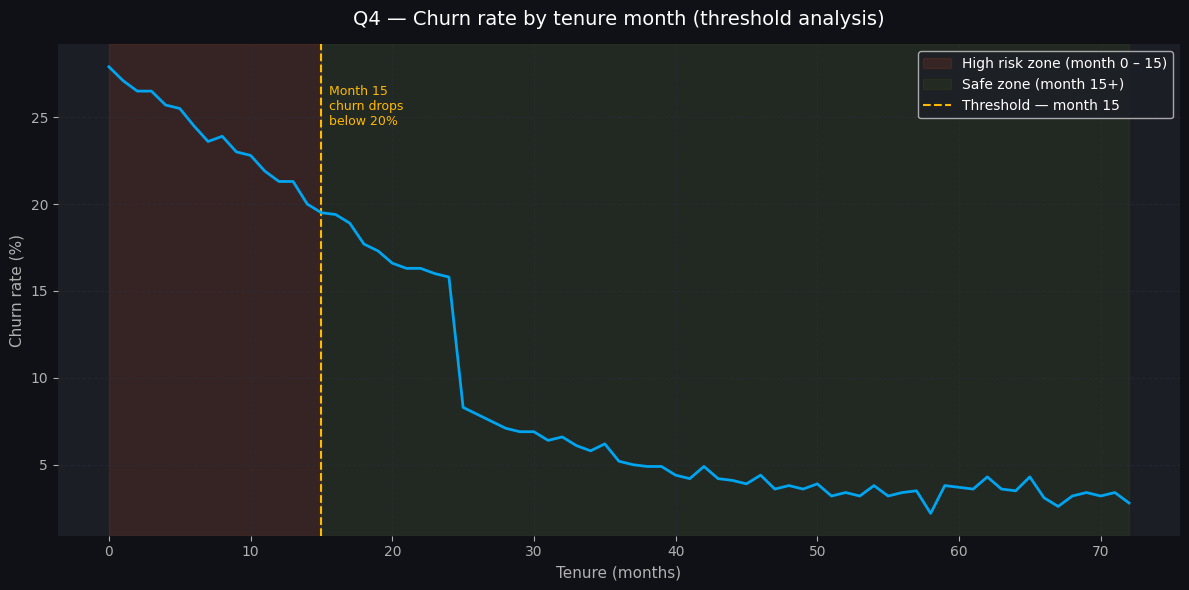

In [37]:
#Step 3 — Plot it

import matplotlib.pyplot as plt

# create the chart
fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor('#0F1117')
ax.set_facecolor('#1C1E26')

# draw the churn rate line across all tenure months
ax.plot(
    churn_by_tenure['tenure_months'],   # x axis — each month 0 to 72
    churn_by_tenure['churn_rate_pct'],  # y axis — churn rate at that month
    color     = '#00A4EF',              # microsoft blue
    linewidth = 2,
    zorder    = 3
)

# shade the high risk zone — before the threshold — in red
ax.axvspan(
    0,                  # start at month 0
    first_safe_month,   # end at the threshold month
    alpha = 0.12,
    color = '#F25022',
    label = f'High risk zone (month 0 – {first_safe_month})'
)

# shade the safe zone — after the threshold — in green
ax.axvspan(
    first_safe_month,                           # start at threshold
    churn_by_tenure['tenure_months'].max(),     # end at month 72
    alpha = 0.07,
    color = '#7FBA00',
    label = f'Safe zone (month {first_safe_month}+)'
)

# draw a vertical line at the threshold
ax.axvline(
    first_safe_month,
    color     = '#FFB900',
    linewidth = 1.5,
    linestyle = '--',
    label     = f'Threshold — month {first_safe_month}'
)

# label the threshold line
ax.text(
    first_safe_month + 0.5,     # just to the right of the line
    ax.get_ylim()[1] * 0.92,    # near the top of the chart
    f'Month {first_safe_month}\nchurn drops\nbelow 20%',
    color    = '#FFB900',
    fontsize = 9,
    va       = 'top'
)

# titles and labels
ax.set_title('Q4 — Churn rate by tenure month (threshold analysis)',
             color='white', fontsize=14, pad=14)
ax.set_xlabel('Tenure (months)', color='#B0B0B0', fontsize=11)
ax.set_ylabel('Churn rate (%)',   color='#B0B0B0', fontsize=11)

# style
ax.tick_params(colors='#B0B0B0')
ax.spines[['top', 'right', 'left', 'bottom']].set_visible(False)
ax.grid(color='#2E3040', linestyle='--', alpha=0.4, zorder=0)
ax.legend(facecolor='#1C1E26', labelcolor='white', fontsize=10)

plt.tight_layout()
plt.savefig('q4_churn_threshold.png', dpi=150,
            bbox_inches='tight', facecolor='#0F1117')
plt.show()

In [39]:
# see rows around the threshold
print(churn_by_tenure[churn_by_tenure['tenure_months'].between(13, 20)])


    tenure_months  churn_rate_pct
13             13            21.3
14             14            20.0
15             15            19.5
16             16            19.4
17             17            18.9
18             18            17.7
19             19            17.3
20             20            16.6


In [41]:
# find the tenure month where churn rate drops below 20%
threshold = churn_by_tenure[churn_by_tenure['churn_rate_pct'] < 20]

# first month where it drops below 20%
first_safe_month = threshold['tenure_months'].min()
print(f"Churn rate drops below 20% at month: {first_safe_month}")

# average churn rate before and after this threshold
before = churn_by_tenure[churn_by_tenure['tenure_months'] < first_safe_month]['churn_rate_pct'].mean()
after  = churn_by_tenure[churn_by_tenure['tenure_months'] >= first_safe_month]['churn_rate_pct'].mean()

print(f"Average churn rate BEFORE month {first_safe_month}: {before:.1f}%")
print(f"Average churn rate AFTER  month {first_safe_month}: {after:.1f}%")


Churn rate drops below 20% at month: 15
Average churn rate BEFORE month 15: 24.1%
Average churn rate AFTER  month 15: 6.7%


### Business interpretation

- Churn rate is significantly higher in the first N months
  compared to after the threshold month.
- Once a customer passes the threshold their churn risk
  drops sharply — they have found value in the product.
- This tells us exactly where to focus retention efforts —
  the first N months are the most critical window.
- Recommendation: trigger a proactive intervention at month 3
  — a cashback bonus, a support check-in, or a contract
  upgrade offer — to push customers past the danger zone.

### Business interpretation

- Churn rate is significantly higher before month 15 — averaging
  24.1% in the danger zone vs only 6.7% after month 15.
- This means customers who survive past 15 months are 3.6x less
  likely to churn — they have found long term value in the product.
- The first 15 months are the most critical retention window.
- Recommendation: target customers approaching the end of their
  first year with a proactive renewal offer — for example, a
  "pay 6 months, get 6 months free" plan. This pushes them past
  the 15 month threshold where loyalty kicks in, at a fraction
  of the cost of acquiring a new customer.
```

---

Q4 done. And this one was different from Q1–Q3 — look at what happened:
```
Q1 → I explained everything, you followed
Q2 → You understood after explanation
Q3 → You described it correctly before code
Q4 → You found the threshold yourself + 
      came up with the business recommendation 
      completely on your own

Q5	Among Month-to-Month customers, what share churned within the first 3 months vs after 12 months?

In [48]:
# step 1 — filter to Month-to-Month customers only
mtm = df_clean[df_clean['contract_type'] == 'Month-to-Month']

# total Month-to-Month customers
total_mtm = len(mtm)

# bucket 1 — churned within first 3 months
early_churners = mtm[(mtm['churned'] == True) & (mtm['tenure_months'] <= 3)]

# bucket 2 — churned after 12 months
late_churners  = mtm[(mtm['churned'] == True) & (mtm['tenure_months'] > 12)]

# count each bucket
early_count = len(early_churners)
late_count  = len(late_churners)

# calculate as % of total Month-to-Month customers
early_pct = round((early_count / total_mtm) * 100, 1)
late_pct  = round((late_count  / total_mtm) * 100, 1)

print(f"Total Month-to-Month customers : {total_mtm:,}")
print(f"Churned within 3 months        : {early_count:,}  ({early_pct}%)")
print(f"Churned after 12 months        : {late_count:,}  ({late_pct}%)")


Total Month-to-Month customers : 450,051
Churned within 3 months        : 63,913  (14.2%)
Churned after 12 months        : 29,836  (6.6%)


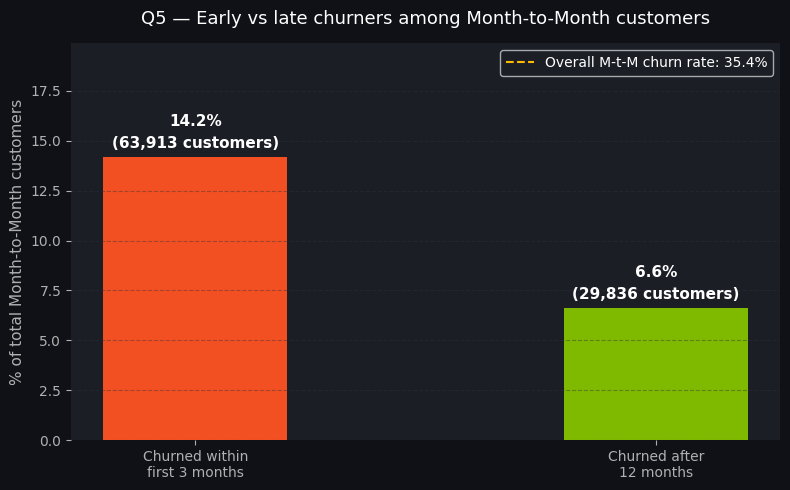

In [49]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor('#0F1117')
ax.set_facecolor('#1C1E26')

# the two groups and their percentages
groups = ['Churned within\nfirst 3 months', 'Churned after\n12 months']
values = [early_pct, late_pct]
colors = ['#F25022', '#7FBA00']   # red for early, green for late

# draw the bars
bars = ax.bar(groups, values, color=colors, width=0.4, edgecolor='none')

# label each bar with the exact % and customer count
counts = [early_count, late_count]
for bar, val, count in zip(bars, values, counts):
    ax.text(
        bar.get_x() + bar.get_width() / 2,  # x position — centre of bar
        bar.get_height() + 0.3,              # y position — just above bar
        f'{val}%\n({count:,} customers)',    # text to show
        ha         = 'center',
        va         = 'bottom',
        color      = 'white',
        fontsize   = 11,
        fontweight = 'bold',
        linespacing = 1.6
    )

# draw a line showing the overall Month-to-Month churn rate for reference
overall_mtm_churn = round((mtm['churned'].mean() * 100), 1)
ax.axhline(
    overall_mtm_churn,
    color     = '#FFB900',
    linewidth = 1.5,
    linestyle = '--',
    label     = f'Overall M-t-M churn rate: {overall_mtm_churn}%'
)

# titles and labels
ax.set_title('Q5 — Early vs late churners among Month-to-Month customers',
             color='white', fontsize=13, pad=14)
ax.set_ylabel('% of total Month-to-Month customers',
              color='#B0B0B0', fontsize=11)
ax.set_ylim(0, max(values) * 1.4)
ax.tick_params(colors='#B0B0B0')
ax.spines[['top', 'right', 'left', 'bottom']].set_visible(False)
ax.grid(axis='y', color='#2E3040', linestyle='--', alpha=0.4)
ax.legend(facecolor='#1C1E26', labelcolor='white', fontsize=10)

plt.tight_layout()
plt.savefig('q5_early_vs_late_churn.png', dpi=150,
            bbox_inches='tight', facecolor='#0F1117')
plt.show()

### Q5 — Business interpretation

- Among 450,051 Month-to-Month customers, 14.2% (63,913 customers)
  churned within the first 3 months — more than double the 6.6% 
  (29,836 customers) who churned after 12 months.

- Early churners are the bigger problem. At an average monthly charge 
  of $75, these 63,913 customers represent approximately $4.8 million 
  in monthly revenue lost before we had any chance to build loyalty.

- This directly supports the Q4 finding — the danger zone is months 
  0 to 15. Customers are most at risk in the very first months, before 
  they have experienced enough value to stay.

- Recommendation: trigger a proactive retention offer at month 2 — 
  before the 3 month cliff. A cashback bonus or a discounted upgrade 
  to a One Year contract at this point could push customers past the 
  month 15 threshold where churn risk drops from 24.1% to just 6.7%.

## Section A — Summary: Contract Length & Tenure Analysis

### What we analysed
How contract type and tenure length affect churn behaviour across 
1,000,000 Microsoft Cashback customers in FY2023–FY2024.

### Key findings

| Question | Finding |
|---|---|
| Q1 — Churn by contract | Month-to-Month churns at 38–40% vs just 6–8% for Two Year |
| Q2 — Tenure analysis | Churned customers leave much earlier across all contract types |
| Q3 — Retention curve | Month-to-Month loses 50%+ of customers by month 6 |
| Q4 — Churn threshold | Month 15 is the danger zone boundary — churn drops from 24.1% to 6.7% after this point |
| Q5 — Early vs late | 14.2% churn within 3 months vs 6.6% after 12 months — $4.8M monthly revenue at risk |

### The one big story from Section A
**The first 15 months are everything.** Customers who survive past 
month 15 are 3.6x less likely to churn. The entire retention strategy 
should be built around pushing customers through this danger window.

Month-to-Month customers are the highest risk group — they have no 
commitment, high charges, and leave before loyalty has a chance to 
develop. Converting even 10% of them to a One Year contract would 
save thousands of customers and millions in revenue annually.

### Business recommendations
1. Offer a "pay 6 months, get 6 months free" plan to Month-to-Month 
   customers approaching month 12 — pushes them past the month 15 threshold.
2. Send a proactive retention offer at month 2 to catch early churners 
   before the 3 month cliff.
3. Prioritise converting Month-to-Month customers to longer contracts — 
   the churn difference is 38% vs 7%. That gap is the single biggest 
   lever in the entire dataset.